In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
import json
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO

from PepMLM_gen_scripts.pepmlm_generate_fast import PepMLMConfig, run_pepmlm
from MetaLATTE_gen_scripts.run_metalatte_fasta import run_metalatte_on_fasta


# ============================================================
# CONFIG DATA STRUCTURES
# ============================================================

@dataclass
class SeedSet:
    name: str          # e.g. "pb_mer_operon"
    fasta_path: Path   # path to seeds fasta file


@dataclass
class PepMLMParams:
    n_variants_per_seed: int = 20
    fraction_mask: float = 0.10
    topk_per_mask: int = 5
    max_len: int = 200
    batch_size: int = 8


@dataclass
class RunConfig:
    """
    A single experiment configuration (one 'run'):
      - same PepMLM params for all seed sets
      - novelty threshold (used post-hoc, after BLAST),
      - how many top variants to keep per seed.
    """
    name: str
    out_dir: Path
    pepmlm_params: PepMLMParams
    novelty_identity_threshold: float = 0.95  # fraction: e.g. 0.7 = 70% identity
    top_k_variants: int = 200


# ============================================================
# UTILS
# ============================================================

def load_fasta_as_dict(fasta_path: Path) -> Dict[str, str]:
    """Return {id: sequence} from a FASTA file."""
    records = SeqIO.parse(str(fasta_path), "fasta")
    return {r.id: str(r.seq) for r in records}


def compute_binding_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add binding_capacity and best_metal columns from MetaLATTE prob_* columns.
    Assumes columns like prob_Pb, prob_Hg, prob_Non_binding, etc.
    """
    metal_cols = [
        c for c in df.columns
        if c.startswith("prob_") and "Non" not in c and "non" not in c
    ]
    if not metal_cols:
        raise ValueError("No metal prob_ columns found in MetaLATTE output.")

    df["binding_capacity"] = df[metal_cols].max(axis=1)
    df["best_metal"] = df[metal_cols].idxmax(axis=1).str.replace("prob_", "")
    return df


def _find_sequence_id_column(df: pd.DataFrame) -> str:
    """
    Try to infer the column that contains the sequence identifier
    (the FASTA header used as BLAST qseqid).
    """
    candidates = ["sequence_id", "seq_id", "id", "name"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Could not find a sequence ID column in MetaLATTE output. "
        f"Expected one of {candidates}."
    )


# ============================================================
# CORE PIPELINE FOR ONE SEED SET WITHIN A RUN
# ============================================================

def run_for_seed_set(seed: SeedSet, run_cfg: RunConfig) -> Tuple[pd.DataFrame, Path]:
    """
    Run PepMLM + MetaLATTE for a single seed set within a run,
    compute binding metrics, and return (dataframe, variants_fasta_path).

    NOTE: Novelty (vs seeds) is NOT computed here anymore.
          That is now done post-hoc using external BLAST results.
    """
    run_dir = run_cfg.out_dir
    run_dir.mkdir(parents=True, exist_ok=True)

    seed_subdir = run_dir / f"seed_{seed.name}"
    seed_subdir.mkdir(exist_ok=True)

    # 1. Generate variants with PepMLM
    variants_fasta = seed_subdir / "generated_variants.fasta"

    pep_cfg = PepMLMConfig(
        fasta_in=seed.fasta_path,
        fasta_out=variants_fasta,
        n_variants_per_seed=run_cfg.pepmlm_params.n_variants_per_seed,
        fraction_mask=run_cfg.pepmlm_params.fraction_mask,
        topk_per_mask=run_cfg.pepmlm_params.topk_per_mask,
        max_len=run_cfg.pepmlm_params.max_len,
        batch_size=run_cfg.pepmlm_params.batch_size,
    )
    print(f"[{run_cfg.name}] Running PepMLM for seed set '{seed.name}'")
    run_pepmlm(pep_cfg)

    # 2. Run MetaLATTE on generated variants
    metalatte_csv = seed_subdir / "metalatte_predictions.csv"
    print(f"[{run_cfg.name}] Running MetaLATTE for seed set '{seed.name}'")
    run_metalatte_on_fasta(
        fasta_path=str(variants_fasta),
        out_csv_path=str(metalatte_csv),
    )

    df = pd.read_csv(metalatte_csv)

    # 3. Add binding metrics
    df = compute_binding_metrics(df)

    # sanity check: we expect both sequence_id and sequence to exist
    if "sequence" not in df.columns:
        raise ValueError(
            "Expected a 'sequence' column in MetaLATTE output; "
            "adjust code if it's named differently."
        )

    seq_id_col = _find_sequence_id_column(df)
    if seq_id_col != "sequence_id":
        df = df.rename(columns={seq_id_col: "sequence_id"})

    # annotate with seed set & run name
    df["seed_set"] = seed.name
    df["run_name"] = run_cfg.name

    # 4. Save per-seed-set top variants (by binding only)
    top_df = df.sort_values("binding_capacity", ascending=False).head(run_cfg.top_k_variants)
    top_df.to_csv(seed_subdir / "top_variants_binding_only.csv", index=False)

    print(f"[{run_cfg.name}] Done for seed set '{seed.name}' "
          f"({len(df)} variants).")

    # No novelty / identity histograms here; that’s post-hoc now
    return df, variants_fasta


# ============================================================
# RUNNING ONE EXPERIMENT (ALL SEED FILES AT ONCE)
# ============================================================

def run_experiment(seed_sets: List[SeedSet], run_cfg: RunConfig) -> None:
    """
    Run a full experiment:
      - all seed sets with the same PepMLM hyperparams,
      - aggregate into a single CSV,
      - prepare a combined FASTA for BLAST-based novelty analysis.

    Novelty is NOT computed in this step. It is done later using BLAST
    via `add_novelty_from_blast`.
    """
    print("=" * 70)
    print(f"Running experiment: {run_cfg.name}")
    print("=" * 70)

    run_cfg.out_dir.mkdir(parents=True, exist_ok=True)

    # Save run config for reproducibility
    with open(run_cfg.out_dir / "run_config.json", "w") as f:
        json.dump(asdict(run_cfg), f, indent=2, default=str)

    all_variants: List[pd.DataFrame] = []
    all_variant_fastas: List[Path] = []

    for seed in seed_sets:
        df_seed, variants_fasta = run_for_seed_set(seed, run_cfg)
        all_variants.append(df_seed)
        all_variant_fastas.append(variants_fasta)

    all_df = pd.concat(all_variants, ignore_index=True)

    # Save aggregated variants with scores for this run (binding metrics only)
    all_csv = run_cfg.out_dir / "all_variants_with_scores.csv"
    all_df.to_csv(all_csv, index=False)
    print(f"[{run_cfg.name}] Saved all variant scores → {all_csv}")

    # Build a combined FASTA of all generated variants for this run.
    # This is the file you will feed into BLAST externally.
    combined_fasta = run_cfg.out_dir / "all_variants_for_blast.fasta"
    with open(combined_fasta, "w") as fout:
        for fasta_path in all_variant_fastas:
            with open(fasta_path, "r") as fin:
                fout.write(fin.read())
    print(f"[{run_cfg.name}] Saved combined FASTA for BLAST → {combined_fasta}")

    print(f"[{run_cfg.name}] RUN COMPLETE (binding scores only; "
          f"novelty to be added post-hoc).")


# ============================================================
# POST-HOC NOVELTY VIA BLAST
# ============================================================

def load_blast_results(blast_tsv: Path) -> pd.DataFrame:
    """
    Load BLAST results (outfmt 6) and compute max percent identity
    per query sequence (qseqid).

    BLAST command example (run outside Python):

        makeblastdb -in SEEDS.fasta -dbtype prot -out seeds_db

        blastp -query all_variants_for_blast.fasta \\
               -db seeds_db \\
               -out blast_results.tsv \\
               -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore"
    """
    colnames = [
        "qseqid", "sseqid", "pident", "length",
        "mismatch", "gapopen", "qstart", "qend",
        "sstart", "send", "evalue", "bitscore",
    ]
    df = pd.read_csv(blast_tsv, sep="\t", header=None, names=colnames)

    # max identity per query
    df_max = (
        df.groupby("qseqid")["pident"]
        .max()
        .reset_index()
        .rename(columns={"pident": "max_identity_to_seed_pct"})
    )
    return df_max


def add_novelty_from_blast(run_cfg: RunConfig, blast_tsv: Path) -> pd.DataFrame:
    """
    Post-hoc step: after all variants are generated and BLAST has been run
    externally, merge BLAST-based novelty onto the run's variants, compute
    per-seed summaries, and generate identity histograms.

    Returns the full dataframe with novelty columns.
    """
    print("=" * 70)
    print(f"[{run_cfg.name}] Adding novelty from BLAST results: {blast_tsv}")
    print("=" * 70)

    all_csv = run_cfg.out_dir / "all_variants_with_scores.csv"
    if not all_csv.exists():
        raise FileNotFoundError(
            f"Expected aggregated variants CSV not found: {all_csv}. "
            f"Did you run run_experiment() first?"
        )

    all_df = pd.read_csv(all_csv)

    if "sequence_id" not in all_df.columns:
        seq_id_col = _find_sequence_id_column(all_df)
        if seq_id_col != "sequence_id":
            all_df = all_df.rename(columns={seq_id_col: "sequence_id"})

    blast_df = load_blast_results(blast_tsv)

    # Merge BLAST identities: BLAST qseqid should match FASTA headers,
    # which should match MetaLATTE's sequence_id.
    merged = all_df.merge(
        blast_df,
        how="left",
        left_on="sequence_id",
        right_on="qseqid",
    )

    # Sequences with no BLAST hit → treat as 0% identity (maximally novel)
    merged["max_identity_to_seed_pct"] = merged["max_identity_to_seed_pct"].fillna(0.0)

    # Convert to fraction 0–1 for consistency
    merged["max_identity_to_seed"] = merged["max_identity_to_seed_pct"] / 100.0
    merged["is_novel"] = merged["max_identity_to_seed"] < run_cfg.novelty_identity_threshold

    # Save updated variants table
    updated_csv = run_cfg.out_dir / "all_variants_with_scores_and_novelty.csv"
    merged.to_csv(updated_csv, index=False)
    print(f"[{run_cfg.name}] Saved variants with BLAST-based novelty → {updated_csv}")

    # Per-seed summary including novelty percentage & binding capacity stats
    summary = (
        merged
        .groupby("seed_set")
        .agg(
            n_variants=("sequence", "count"),
            novelty_pct=("is_novel", lambda x: 100.0 * x.mean()),
            mean_binding_capacity=("binding_capacity", "mean"),
            max_binding_capacity=("binding_capacity", "max"),
        )
        .reset_index()
    )

    summary_csv = run_cfg.out_dir / "summary_by_seed.csv"
    summary.to_csv(summary_csv, index=False)
    print(f"[{run_cfg.name}] Saved summary by seed set → {summary_csv}")

    # Identity histograms per seed set (now using BLAST identities)
    plots_dir = run_cfg.out_dir / "plots"
    plots_dir.mkdir(exist_ok=True)
    for seed_name, sub in merged.groupby("seed_set"):
        plt.figure()
        plt.hist(sub["max_identity_to_seed"], bins=30)
        plt.xlabel("Max sequence identity to any seed (BLAST)")
        plt.ylabel("Count of generated variants")
        plt.title(f"{run_cfg.name} – {seed_name} – similarity to seeds (BLAST)")
        plt.tight_layout()
        img_path = plots_dir / f"identity_hist_{seed_name}.png"
        plt.savefig(img_path, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"[{run_cfg.name}] Saved similarity histogram → {img_path}")

    print(f"[{run_cfg.name}] Novelty integration DONE.")
    return merged


# ============================================================
# ABLATION ANALYSIS – COMPARING MULTIPLE RUNS
# ============================================================

def load_run_summary(run_dir: Path) -> pd.DataFrame:
    summary_path = run_dir / "summary_by_seed.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Summary file not found: {summary_path}")
    df = pd.read_csv(summary_path)
    df["run_dir"] = str(run_dir)
    df["run_name"] = run_dir.name
    return df


def compare_runs(run_dirs: List[Path]) -> pd.DataFrame:
    """
    Load summaries from multiple runs and return combined dataframe.
    You can then plot novelty vs binding capacity for ablation analysis.

    Assumes you've already run add_novelty_from_blast for each run so that
    summary_by_seed.csv contains a 'novelty_pct' column.
    """
    all_summaries = [load_run_summary(rd) for rd in run_dirs]
    combined = pd.concat(all_summaries, ignore_index=True)

    plt.figure()
    for run_name, sub in combined.groupby("run_name"):
        plt.scatter(
            sub["novelty_pct"],
            sub["mean_binding_capacity"],
            label=run_name,
        )
    plt.xlabel("Novelty % (< threshold identity)")
    plt.ylabel("Mean binding capacity")
    plt.title("Run comparison: novelty vs binding capacity (BLAST-based)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return combined


In [2]:
seed_sets = [
    SeedSet("pb_mer_operon", Path("PepMLM_seeds/Metal_specific/pb_seeds.fasta")),
    SeedSet("hg_specific", Path("PepMLM_seeds/Metal_specific/hg_seeds.fasta")),
    SeedSet("cd_specific", Path("PepMLM_seeds/Metal_specific/cd_seeds.fasta")),
    SeedSet("MT_bacterial_redox", Path("PepMLM_seeds/MT_seeds/MT_Bacterial_Redox.fasta")),
    SeedSet("MT_bacterial_transformation", Path("PepMLM_seeds/MT_seeds/MT_Bacterial_transformation.fasta")),
]

# 2) Define different runs with different hyperparameters (for ablation)
base_params = PepMLMParams(
    n_variants_per_seed=20,
    fraction_mask=0.10,   # fewer positions masked → more conservative
    topk_per_mask=5,      # or whatever you want to test
    max_len=200,
    batch_size=8,
)

low_mask_params = PepMLMParams(
    n_variants_per_seed=20,
    fraction_mask=0.05,   # fewer positions masked → more conservative
    topk_per_mask=5,      # or whatever you want to test
    max_len=200,
    batch_size=8,
)

high_mask_params = PepMLMParams(
    n_variants_per_seed=20,
    fraction_mask=0.25,   # fewer positions masked → more conservative
    topk_per_mask=5,      # or whatever you want to test
    max_len=200,
    batch_size=8,
)

topk_values = [1, 3, 5, 10]

runs = [
    RunConfig(
        name=f"run_topk_{k}",
        out_dir=Path(f"notebook_runs/run_topk_{k}"),
        pepmlm_params=PepMLMParams(
            n_variants_per_seed=20,
            fraction_mask=high_mask_params.fraction_mask,
            topk_per_mask=k,
            max_len=200,
            batch_size=8,
        ),
        novelty_identity_threshold=0.95,
        top_k_variants=999999,
    )
    for k in topk_values
]



for cfg in runs:
    run_experiment(seed_sets, cfg)


Running experiment: run_topk_1
[run_topk_1] Running PepMLM for seed set 'pb_mer_operon'
[23:03:16] loading PepMLM model/tokenizer…
[23:03:17] device: cpu; threads: 4
[23:03:17] seed sp_P38990_SAK1_YEAST (len 1142) …
[23:03:17] skip sp_P38990_SAK1_YEAST: length 1142 > MAX_LEN 200
[23:03:17] seed sp_P04034_LDH1_LACLC (len 325) …
[23:03:17] skip sp_P04034_LDH1_LACLC: length 325 > MAX_LEN 200
[23:03:17] seed sp_P04140_MERT_PSEAI (len 116) …
[23:03:27] seed sp_P25224_MATRX_RABVN (len 202) …
[23:03:27] skip sp_P25224_MATRX_RABVN: length 202 > MAX_LEN 200
[23:03:27] seed sp_Q9ZDL2_DHAS_RICPR (len 338) …
[23:03:27] skip sp_Q9ZDL2_DHAS_RICPR: length 338 > MAX_LEN 200
[23:03:27] seed tr_Q7MGP3_Q7MGP3_VIBVY (len 625) …
[23:03:27] skip tr_Q7MGP3_Q7MGP3_VIBVY: length 625 > MAX_LEN 200
[23:03:27] seed sp_P81803_TTF17_HADVE (len 68) …
[23:03:34] seed tr_Q9LT07_Q9LT07_ARATH (len 175) …
[23:03:48] seed tr_Q9ZDL3_Q9ZDL3_RICPR (len 583) …
[23:03:48] skip tr_Q9ZDL3_Q9ZDL3_RICPR: length 583 > MAX_LEN 200
[

Seed set to 42
Seed set to 42


[run_topk_1] Running MetaLATTE for seed set 'pb_mer_operon'


Some weights of EsmModel were not initialized from the model checkpoint at /workarea/AML_Final_Project/esm2_local/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[warn] unexpected keys (ignored): ['esm_model.embeddings.position_embeddings.weight']
✓ wrote notebook_runs/run_topk_1/seed_pb_mer_operon/metalatte_predictions.csv
[run_topk_1] Done for seed set 'pb_mer_operon' (120 variants).
[run_topk_1] Running PepMLM for seed set 'hg_specific'
[23:07:32] loading PepMLM model/tokenizer…
[23:07:34] device: cpu; threads: 4
[23:07:34] seed sp_D9J041_MERA_LYSSH (len 546) …
[23:07:34] skip sp_D9J041_MERA_LYSSH: length 546 > MAX_LEN 200
[23:07:34] seed sp_P00392_MERA_PSEAI (len 561) …
[23:07:34] skip sp_P00392_MERA_PSEAI: length 561 > MAX_LEN 200
[23:07:34] seed sp_P04140_MERT_PSEAI (len 116) …
[23:07:44] seed sp_P16171_MERA_BACCE (len 631) …
[23:07:44] skip sp_P16171_MERA_BACCE: length 631 > MAX_LEN 200
[23:07:44] seed sp_P04131_MERP_PSEAI (len 91) …
[23:07:52] seed sp_P08332_MERA_SHIFL (len 564) …
[23:07:52] skip sp_P08332_MERA_SHIFL: length 564 > MAX_LEN 200
[23:07:52] seed sp_P08662_MERA_SERMA (len 460) …
[23:07:52] skip sp_P08662_MERA_SERMA: length 4

...

[run_topk_10] Running MetaLATTE for seed set 'cd_specific'
[warn] unexpected keys (ignored): ['esm_model.embeddings.position_embeddings.weight']
✓ wrote notebook_runs/run_topk_10/seed_cd_specific/metalatte_predictions.csv
[run_topk_10] Done for seed set 'cd_specific' (160 variants).
[run_topk_10] Running PepMLM for seed set 'MT_bacterial_redox'
[00:05:06] loading PepMLM model/tokenizer…
[00:05:10] device: cpu; threads: 4
[00:05:10] seed sp_P06616_ERA_ECOLI (len 301) …
[00:05:10] skip sp_P06616_ERA_ECOLI: length 301 > MAX_LEN 200
[00:05:10] seed sp_P07228_ITB1_CHICK (len 803) …
[00:05:10] skip sp_P07228_ITB1_CHICK: length 803 > MAX_LEN 200
[00:05:10] seed sp_P0A6Y8_DNAK_ECOLI (len 638) …
[00:05:10] skip sp_P0A6Y8_DNAK_ECOLI: length 638 > MAX_LEN 200
[00:05:10] seed sp_P0A9D8_DAPD_ECOLI (len 274) …
[00:05:10] skip sp_P0A9D8_DAPD_ECOLI: length 274 > MAX_LEN 200
[00:05:10] seed sp_P0AA25_THIO_ECOLI (len 109) …
[00:05:19] seed sp_P14907_NSP1_YEAST (len 823) …
[00:05:19] skip sp_P14907_NSP1_

Seed set to 42
Some weights of EsmModel were not initialized from the model checkpoint at /workarea/AML_Final_Project/esm2_local/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[run_topk_10] Running MetaLATTE for seed set 'MT_bacterial_redox'
[warn] unexpected keys (ignored): ['esm_model.embeddings.position_embeddings.weight']
✓ wrote notebook_runs/run_topk_10/seed_MT_bacterial_redox/metalatte_predictions.csv
[run_topk_10] Done for seed set 'MT_bacterial_redox' (120 variants).
[run_topk_10] Running PepMLM for seed set 'MT_bacterial_transformation'
[00:09:05] loading PepMLM model/tokenizer…
[00:09:06] device: cpu; threads: 4
[00:09:06] seed sp_P0CS90_HSP77_YEAST (len 654) …
[00:09:06] skip sp_P0CS90_HSP77_YEAST: length 654 > MAX_LEN 200
[00:09:06] seed sp_P0CS91_HSP77_YEASX (len 655) …
[00:09:06] skip sp_P0CS91_HSP77_YEASX: length 655 > MAX_LEN 200
[00:09:06] seed sp_P27635_RL10_HUMAN (len 214) …
[00:09:06] skip sp_P27635_RL10_HUMAN: length 214 > MAX_LEN 200
[00:09:06] seed sp_Q99383_HRP1_YEAST (len 534) …
[00:09:06] skip sp_Q99383_HRP1_YEAST: length 534 > MAX_LEN 200
[00:09:06] seed sp_Q9TXQ1_TNKS1_CAEEL (len 2276) …
[00:09:06] skip sp_Q9TXQ1_TNKS1_CAEEL: len

Seed set to 42
Some weights of EsmModel were not initialized from the model checkpoint at /workarea/AML_Final_Project/esm2_local/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[run_topk_10] Running MetaLATTE for seed set 'MT_bacterial_transformation'
[warn] unexpected keys (ignored): ['esm_model.embeddings.position_embeddings.weight']
✓ wrote notebook_runs/run_topk_10/seed_MT_bacterial_transformation/metalatte_predictions.csv
[run_topk_10] Done for seed set 'MT_bacterial_transformation' (40 variants).
[run_topk_10] Saved all variant scores → notebook_runs/run_topk_10/all_variants_with_scores.csv
[run_topk_10] Saved combined FASTA for BLAST → notebook_runs/run_topk_10/all_variants_for_blast.fasta
[run_topk_10] RUN COMPLETE (binding scores only; novelty to be added post-hoc).


In [3]:
from Bio import pairwise2, SeqIO
import pandas as pd
from pathlib import Path
import numpy as np

def compute_max_identity(seq, seed_seqs):
    """Global alignment identity vs all seeds (slow)."""
    max_id = 0
    for s in seed_seqs:
        aln = pairwise2.align.globalxx(seq, s, one_alignment_only=True)[0]
        # compute identity
        matches = sum(a == b for a, b in zip(aln.seqA, aln.seqB))
        length = max(len(aln.seqA.replace("-", "")), len(aln.seqB.replace("-", "")))
        if length > 0:
            ident = matches / length
            if ident > max_id:
                max_id = ident
    return max_id


def add_novelty_slow(run_dir: Path, seed_sets, novelty_threshold=0.95):
    """
    Computes novelty for all sequences in a run using slow pairwise global alignment.
    Produces a new file: all_variants_with_scores_and_novelty.csv
    """

    # Load run variants
    df_path = run_dir / "all_variants_with_scores.csv"
    df = pd.read_csv(df_path)

    # Build a list of all seed sequences used in the run
    seed_seqs = []
    for seed in seed_sets:
        for record in SeqIO.parse(str(seed.fasta_path), "fasta"):
            seed_seqs.append(str(record.seq))

    print(f"[{run_dir.name}] Computing novelty for {len(df)} sequences against {len(seed_seqs)} seeds...")
    
    identities = []
    for i, seq in enumerate(df["sequence"]):
        if i % 25 == 0:
            print(f"  {i}/{len(df)}...")
        identities.append(compute_max_identity(seq, seed_seqs))

    df["max_identity_to_seed"] = identities
    df["is_novel"] = df["max_identity_to_seed"] < novelty_threshold

    out_path = run_dir / "all_variants_with_scores_and_novelty.csv"
    df.to_csv(out_path, index=False)
    print(f"[{run_dir.name}] Saved novelty → {out_path}")

    return df


/opt/bb/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [4]:
from pathlib import Path

run_dirs = [
    Path("notebook_runs/run_topk_1"),
    Path("notebook_runs/run_topk_3"),
    Path("notebook_runs/run_topk_5"),
    Path("notebook_runs/run_topk_10"),
]

dfs = []

for rd in run_dirs:
    df_with_novelty = add_novelty_slow(rd, seed_sets)
    dfs.append(df_with_novelty)


[run_topk_1] Computing novelty for 560 sequences against 91 seeds...
  0/560...
  25/560...
  50/560...
  75/560...
  100/560...
  125/560...
  150/560...
  175/560...
  200/560...
  225/560...
  250/560...
  275/560...
  300/560...
  325/560...
  350/560...
  375/560...
  400/560...
  425/560...
  450/560...
  475/560...
  500/560...
  525/560...
  550/560...
[run_topk_1] Saved novelty → notebook_runs/run_topk_1/all_variants_with_scores_and_novelty.csv
[run_topk_3] Computing novelty for 560 sequences against 91 seeds...
  0/560...
  25/560...
  50/560...
  75/560...
  100/560...
  125/560...
  150/560...
  175/560...
  200/560...
  225/560...
  250/560...
  275/560...
  300/560...
  325/560...
  350/560...
  375/560...
  400/560...
  425/560...
  450/560...
  475/560...
  500/560...
  525/560...
  550/560...
[run_topk_3] Saved novelty → notebook_runs/run_topk_3/all_variants_with_scores_and_novelty.csv
[run_topk_5] Computing novelty for 560 sequences against 91 seeds...
  0/560...
  25

In [7]:
def plot_pareto_frontiers(df, run_order=None):
    """
    Plot the Pareto frontier of binding_capacity vs. novelty for each run.
    novelty = 1 - max_identity_to_seed
    """

    import numpy as np
    import matplotlib.pyplot as plt

    df = df.copy()
    df["novelty"] = 1 - df["max_identity_to_seed"]

    if run_order is None:
        run_order = sorted(df["run_name"].unique())

    plt.figure(figsize=(8,6))

    for run in run_order:
        sub = df[df["run_name"] == run][["novelty", "binding_capacity"]].dropna()

        # Sort by novelty
        sub = sub.sort_values("novelty")
        nov = sub["novelty"].values
        bc = sub["binding_capacity"].values

        # Compute Pareto frontier: keep points where binding is >= all earlier binding values
        pareto_nov = []
        pareto_bc = []
        best_so_far = -1

        for x, y in zip(nov, bc):
            if y >= best_so_far:
                pareto_nov.append(x)
                pareto_bc.append(y)
                best_so_far = y

        plt.plot(pareto_nov, pareto_bc, marker="o", label=run)

    plt.xlabel("Novelty (1 - identity)")
    plt.ylabel("Binding capacity")
    plt.title("Pareto Frontiers: Novelty vs Binding Capacity per Run")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


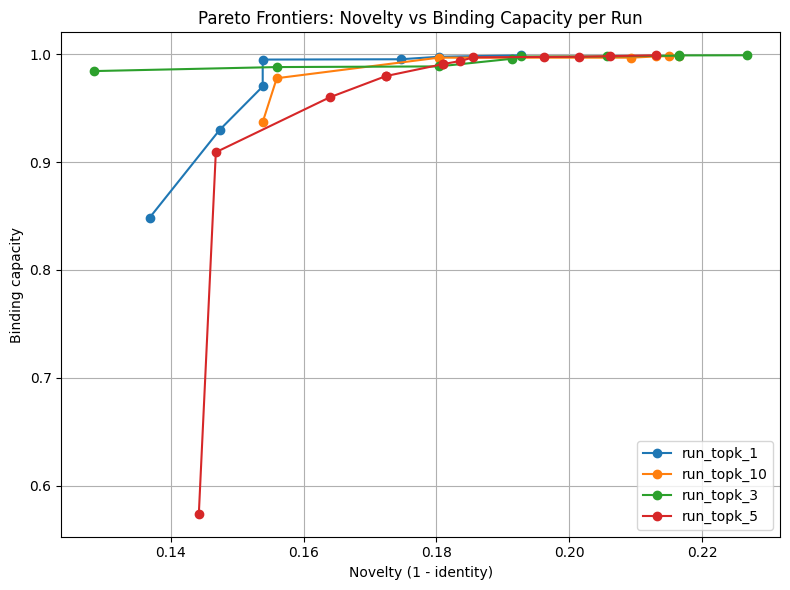

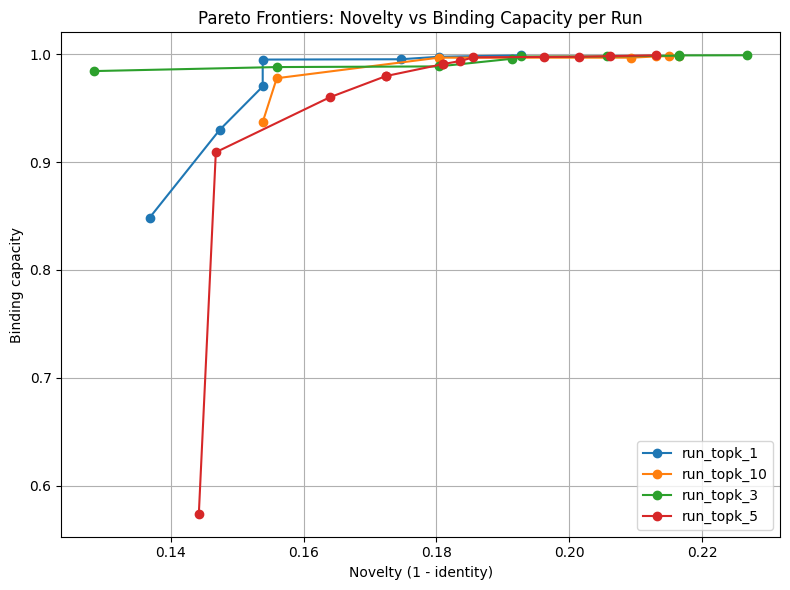

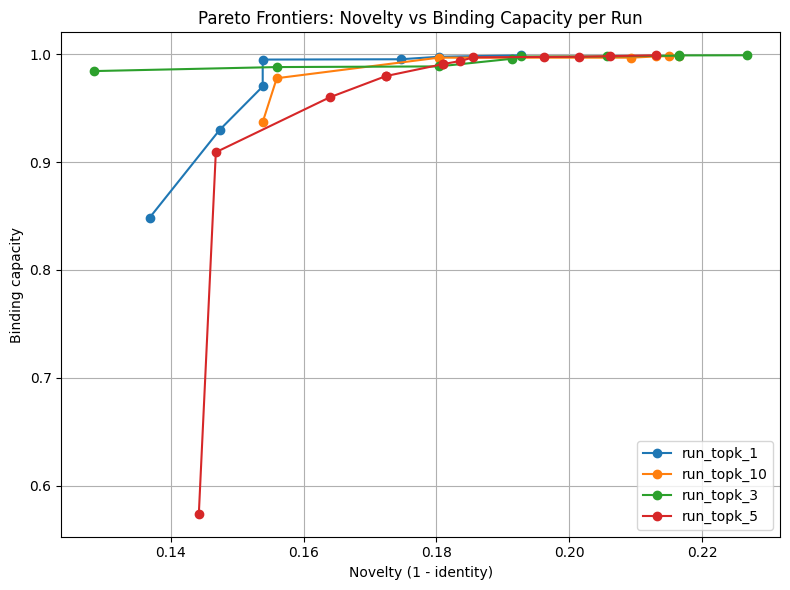

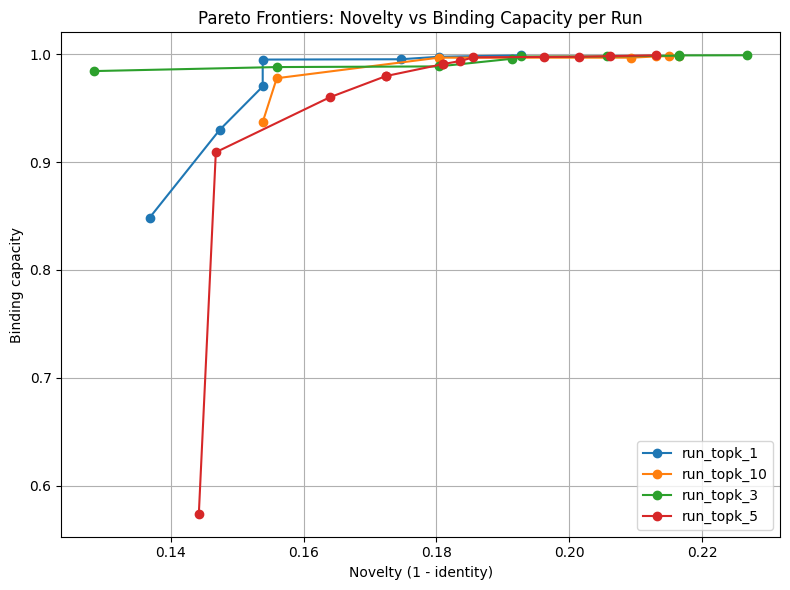

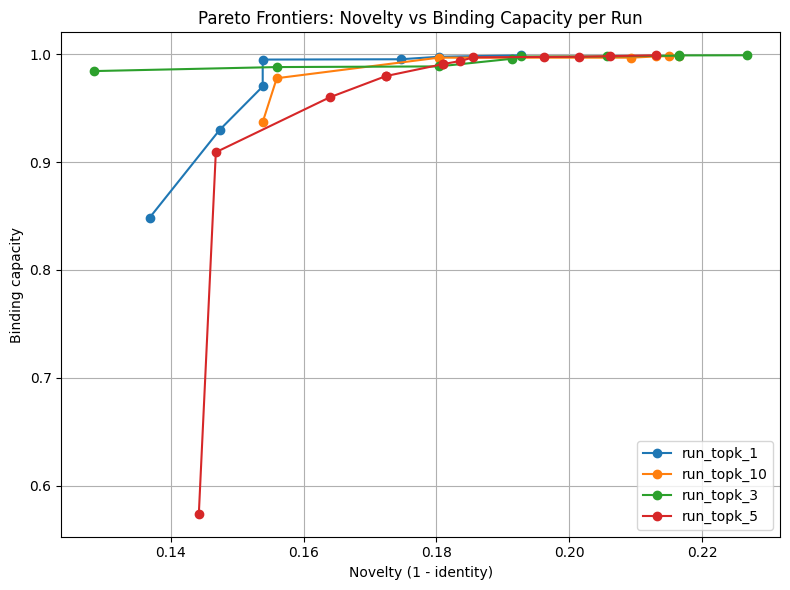

In [11]:
# build combined df
all_variants = pd.concat(
    [pd.read_csv(rd / "all_variants_with_scores_and_novelty.csv") for rd in run_dirs],
    ignore_index=True
)

# your plotting helper from earlier works:
plot_pareto_frontiers(all_variants)

# or:
for rd in run_dirs:
    plot_pareto_frontiers(all_variants)
